In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


After mounting, you can specify the path to your `artists.csv` file. A common path might be `/content/drive/My Drive/Colab Notebooks/artists.csv` if it's directly in your Colab Notebooks folder. Please adjust the path below if your file is located elsewhere.

In [3]:
import pandas as pd

artists_file_path = '/content/drive/My Drive/spotify/artists.csv'
tracks_file_path = '/content/drive/My Drive/spotify/tracks.csv'
dict_artist_path = '/content/drive/My Drive/spotify/dict_artists.json'
artist_df = pd.read_csv(artists_file_path)
df = pd.read_csv(tracks_file_path)
#dict_artist = pd.read_json(dict_artist_path)



## Veri Temizleme

In [4]:
df.shape

(586672, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586672 entries, 0 to 586671
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                586672 non-null  object 
 1   name              586601 non-null  object 
 2   popularity        586672 non-null  int64  
 3   duration_ms       586672 non-null  int64  
 4   explicit          586672 non-null  int64  
 5   artists           586672 non-null  object 
 6   id_artists        586672 non-null  object 
 7   release_date      586672 non-null  object 
 8   danceability      586672 non-null  float64
 9   energy            586672 non-null  float64
 10  key               586672 non-null  int64  
 11  loudness          586672 non-null  float64
 12  mode              586672 non-null  int64  
 13  speechiness       586672 non-null  float64
 14  acousticness      586672 non-null  float64
 15  instrumentalness  586672 non-null  float64
 16  liveness          58

In [4]:
df.isnull().sum()

,0
id,0
name,71
popularity,0
duration_ms,0
explicit,0
artists,0
id_artists,0
release_date,0
danceability,0
energy,0


In [6]:
for col in df.columns:
    sample = df[col].iloc[0]
    print(col, type(sample))

id <class 'str'>
name <class 'str'>
popularity <class 'numpy.int64'>
duration_ms <class 'numpy.int64'>
explicit <class 'numpy.int64'>
artists <class 'str'>
id_artists <class 'str'>
release_date <class 'str'>
danceability <class 'numpy.float64'>
energy <class 'numpy.float64'>
key <class 'numpy.int64'>
loudness <class 'numpy.float64'>
mode <class 'numpy.int64'>
speechiness <class 'numpy.float64'>
acousticness <class 'numpy.float64'>
instrumentalness <class 'numpy.float64'>
liveness <class 'numpy.float64'>
valence <class 'numpy.float64'>
tempo <class 'numpy.float64'>
time_signature <class 'numpy.int64'>


In [5]:
df[df.isnull().any(axis=1)]

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
226336,4iH7negBYMfj2z0wDNmgdx,NaN,28,264973,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1994-01-01,0.512,0.578,0,-12.280,0,0.0299,0.0433,0.000064,0.5160,0.692,156.465,1
510975,04d5kbLvSAIBt3pGcljdhC,NaN,0,184293,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1922-04-01,0.426,0.285,11,-11.970,1,0.0466,0.9950,0.264000,0.2930,0.583,135.661,4
510976,05tRkgyxVdwMePGqOXMDYU,NaN,0,191587,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1922-04-01,0.344,0.186,0,-13.495,1,0.0745,0.9950,0.000000,0.1150,0.290,79.591,1
510978,0YAMRgAQH6tkTh4sWNXr8L,NaN,0,191573,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1922-04-01,0.316,0.257,3,-13.611,0,0.0549,0.9950,0.769000,0.5190,0.529,68.682,3
510979,1K6MQQxmFpPb66ZnaiIpHX,NaN,0,167602,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1922-04-01,0.558,0.283,1,-12.847,1,0.0646,0.9960,0.000000,0.4530,0.608,70.379,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517206,6OH9mz9aFbGlbf74cBwYWD,NaN,2,209760,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1962-02-01,0.506,0.598,7,-4.672,0,0.0635,0.7710,0.000001,0.6910,0.800,91.172,4
517215,15RqFDA86slfzujSQMEX4i,NaN,2,257280,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1962-02-01,0.612,0.615,5,-5.609,1,0.0551,0.8540,0.000023,0.0541,0.809,90.536,4
520127,0hKA9A2JPtFdg0fiMhyjQD,NaN,6,194081,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1974-12-31,0.471,0.369,4,-12.927,0,0.1460,0.9680,0.001100,0.1410,0.766,94.063,4
525238,1kR4gIb7nGxHPI3D2ifs59,NaN,26,289440,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1998-01-05,0.501,0.583,7,-9.460,0,0.0605,0.6900,0.003960,0.0747,0.734,138.391,4


In [6]:
df = df[~df['name'].isnull()]

In [7]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['duration_ms'] = df['duration_ms'] / 1000

In [8]:
df['year'] = df['release_date'].dt.year

In [9]:
df = df.drop_duplicates()
df.shape

(586601, 21)

In [10]:
import ast
df['artists'] = df['artists'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [11]:
df['main_artist'] = df['artists'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) else None
)

In [12]:
df[df['main_artist'].notnull()]

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,year,main_artist
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126.903,0,[Uli],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,...,1,0.4510,0.674,0.744000,0.1510,0.1270,104.851,3,1922.0,Uli
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98.200,0,[Fernando Pessoa],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,...,1,0.9570,0.797,0.000000,0.1480,0.6550,102.009,1,1922.0,Fernando Pessoa
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181.640,0,[Ignacio Corsini],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,...,1,0.0512,0.994,0.021800,0.2120,0.4570,130.418,5,1922.0,Ignacio Corsini
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176.907,0,[Ignacio Corsini],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,...,1,0.0504,0.995,0.918000,0.1040,0.3970,169.980,3,1922.0,Ignacio Corsini
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163.080,0,[Dick Haymes],['3BiJGZsyX9sJchTqcSA7Su'],NaT,0.402,0.1580,...,0,0.0390,0.989,0.130000,0.3110,0.1960,103.220,4,NaN,Dick Haymes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586667,5rgu12WBIHQtvej2MdHSH0,云与海,50,258.267,0,[阿YueYue],['1QLBXKM5GCpyQQSVMNZqrZ'],2020-09-26,0.560,0.5180,...,0,0.0292,0.785,0.000000,0.0648,0.2110,131.896,4,2020.0,阿YueYue
586668,0NuWgxEp51CutD2pJoF4OM,blind,72,153.293,0,[ROLE MODEL],['1dy5WNgIKQU6ezkpZs4y8z'],2020-10-21,0.765,0.6630,...,1,0.0652,0.141,0.000297,0.0924,0.6860,150.091,4,2020.0,ROLE MODEL
586669,27Y1N4Q4U3EfDU5Ubw8ws2,What They'll Say About Us,70,187.601,0,[FINNEAS],['37M5pPGs6V1fchFJSgCguX'],2020-09-02,0.535,0.3140,...,0,0.0408,0.895,0.000150,0.0874,0.0663,145.095,4,2020.0,FINNEAS
586670,45XJsGpFTyzbzeWK8VzR8S,A Day At A Time,58,142.003,0,"[Gentle Bones, Clara Benin]","['4jGPdu95icCKVF31CcFKbS', '5ebPSE9YI5aLeZ1Z2g...",2021-03-05,0.696,0.6150,...,1,0.0345,0.206,0.000003,0.3050,0.4380,90.029,4,2021.0,Gentle Bones


In [13]:
df.loc[586670]

,586670
id,45XJsGpFTyzbzeWK8VzR8S
name,A Day At A Time
popularity,58
duration_ms,142.003
explicit,0
artists,"[Gentle Bones, Clara Benin]"
id_artists,"['4jGPdu95icCKVF31CcFKbS', '5ebPSE9YI5aLeZ1Z2g..."
release_date,2021-03-05 00:00:00
danceability,0.696
energy,0.615


In [14]:
type(df.loc[586670, 'artists'])

list

## Tek Değişkenli Analiz

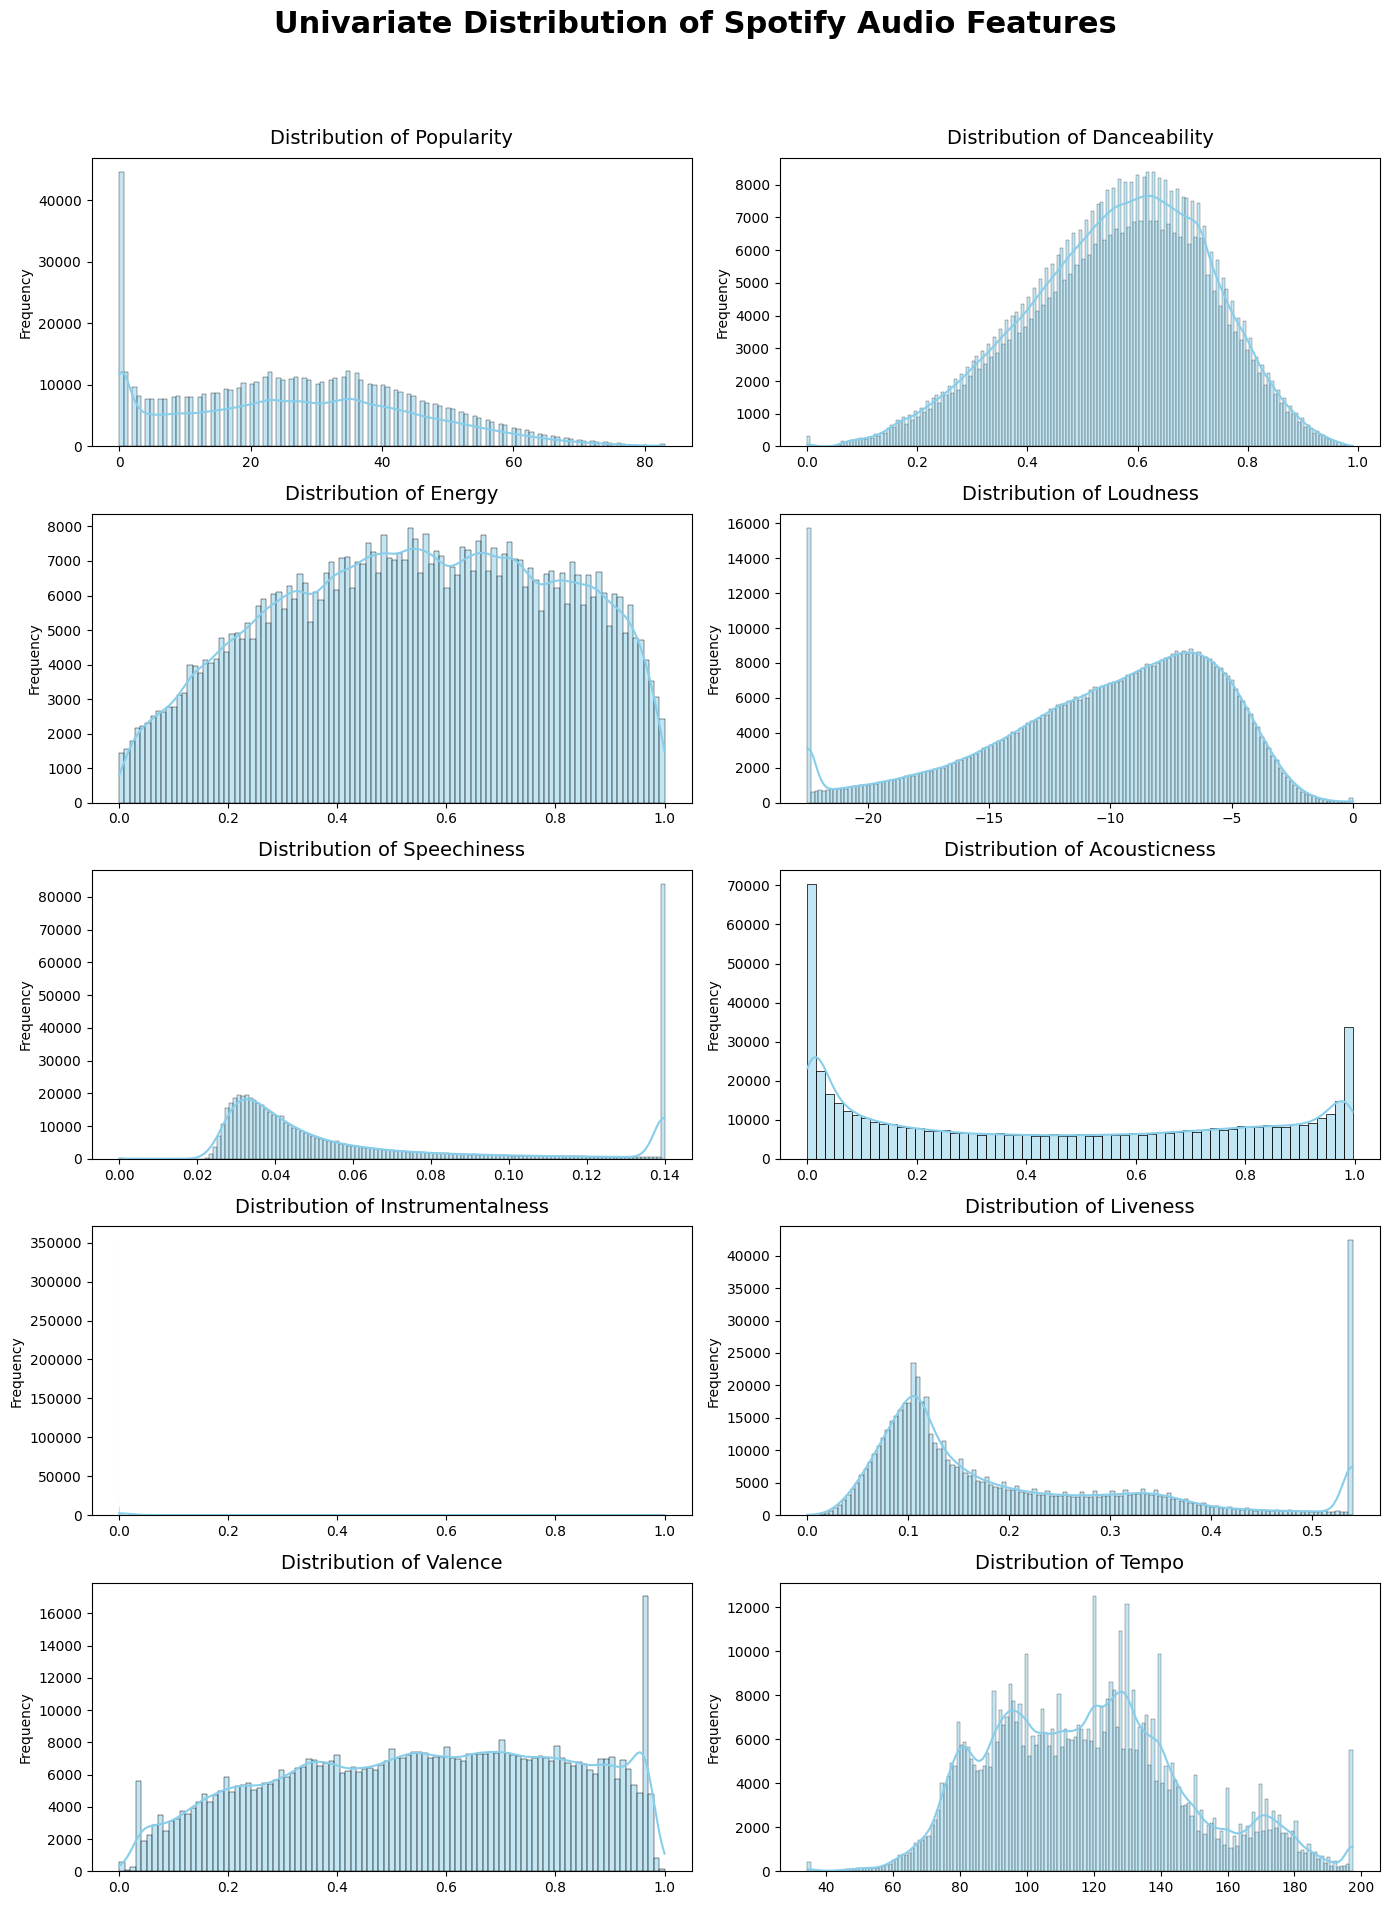

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Veri listesi
var_list = ['popularity', 'danceability', 'energy', 'loudness',
            'speechiness', 'acousticness', 'instrumentalness',
            'liveness', 'valence', 'tempo']

# Grafik düzeni (5 satır, 2 sütun)
rows, cols = 5, 2
fig, axs = plt.subplots(rows, cols, figsize=(14, 20))

# Ana Başlık Ekleme
fig.suptitle('Univariate Distribution of Spotify Audio Features', fontsize=22, fontweight='bold', y=0.98)

# Döngü ile grafikleri çizdirme
for i, var in enumerate(var_list):
    ax = axs.flat[i]
    sns.histplot(data=df, x=var, ax=ax, kde=True, color='skyblue', edgecolor='black')

    # Her bir alt grafik için detaylar
    ax.set_title(f'Distribution of {var.capitalize()}', fontsize=14, pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

# Başlığın grafiklerin üzerine binmesini engellemek için rect ayarı
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



*   Popülerlik genel olarak sağa doğru çarpık, 60 altında yoğunlaşmış şarkılar.
*   Birçok şarkının popülerliği düşüktür.



*   Dans edilebilirlik ve enerji hemen hemen normal dağılım göstermektedir.
*   Ses yüksekliği(Loudness) sola doğru keskin bir çarpıklık göstermektedir.


*   Konuşma, enstrümantallik ve canlılık(liveness) sağa doğru keskin bir çarpıklık göstermektedir.
*   Tempo çok modlu bir dağılım göstermektedir.





## İki Değişkenli Analiz

In [50]:
bivariate_cols = [
    'danceability', 'energy', 'loudness', 'valence',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'tempo'
]

plt.figure(figsize=(20, 25))
plt.suptitle("Popularity vs Audio Features (Bivariate Analysis)", fontsize=20)

sample_df = df.sample(30000)  # sample for performance

for i, col in enumerate(bivariate_cols, 1):
    plt.subplot(5, 2, i)
    sns.scatterplot(data=sample_df, x=col, y='popularity', alpha=0.3)
    sns.regplot(data=sample_df, x=col, y='popularity', scatter=False, color='red')
    plt.title(f"Popularity vs {col}")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Output hidden; open in https://colab.research.google.com to view.

*   Popülerlik, dans edilebilirlik ve enerji ile hafif pozitif bir ilişki göstermektedir.
*   Ses yüksekliği(Loudness), popülerlik ile orta düzeyde korelasyon göstermektedir.

*   Müzikal pozitiflik(Valence), popülerliği önemli ölçüde etkilememektedir.
*   Enstrümantallik ve konuşma sesleri(speechiness) doğrusal olmayan ilişkiler göstermektedir.

*  Tempo, hafif farklılıklar göstermekte olup(sağa doğru), orta ve hızlı tempolar daha iyi performans göstermektedir.

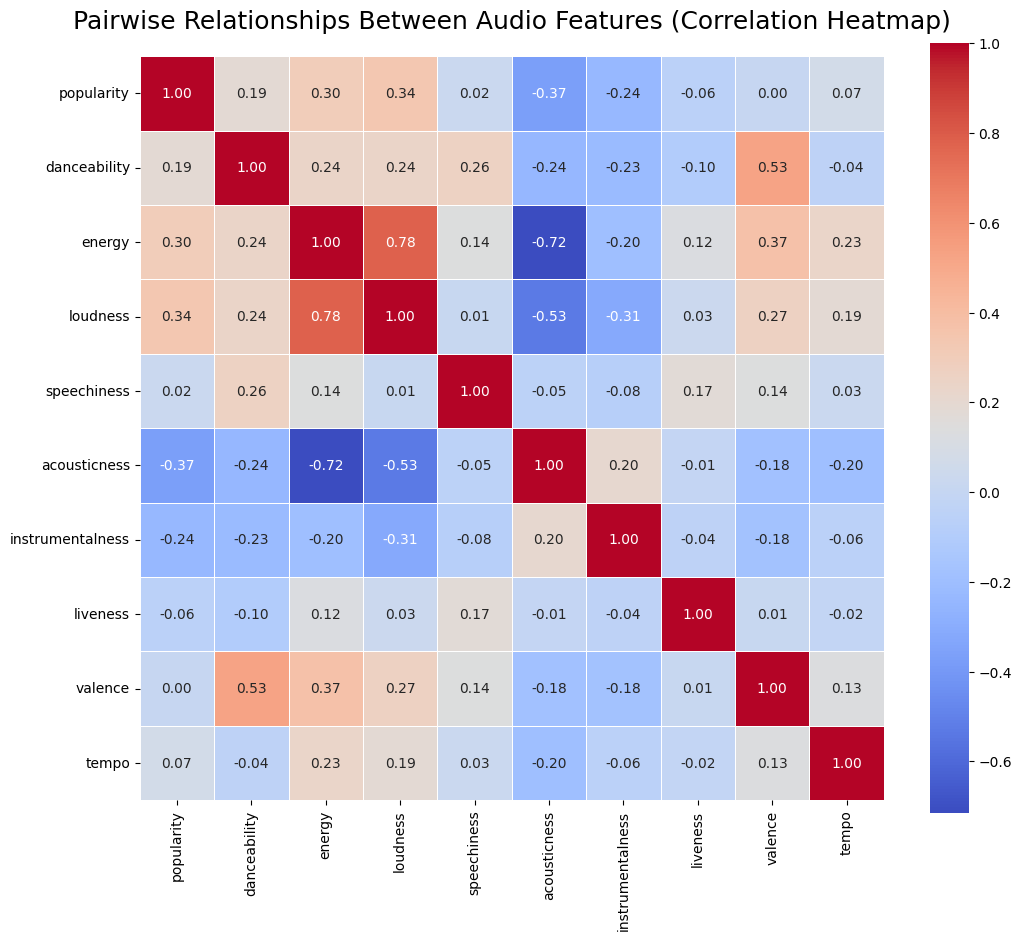

In [52]:
plt.figure(figsize=(12, 10))

# Korelasyon matrisini hesapla
corr_matrix = df[var_list].corr()

# Isı haritasını çizdir
sns.heatmap(corr_matrix,
            annot=True,          # Sayıları üzerine yaz
            fmt=".2f",           # Virgülden sonra 2 basamak
            cmap='coolwarm',     # Renk paleti (Sıcak/Soğuk)
            linewidths=0.5,      # Hücreler arası boşluk
            square=True)         # Hücreleri kare yap

plt.title('Pairwise Relationships Between Audio Features (Correlation Heatmap)', fontsize=18, pad=20)
plt.show()



*   En Güçlü Pozitif İlişki: Enerji & Ses yüksekliği(Loudness) 0.78
*   En Güçlü Negatif İlişki: Enerji & Akustiklik -0.72


*   Popülerlik(Popularity) Üzerindeki Etkiler
    Enerji(0.30) ve Ses yüksekliği(Loudness) (0.33): Popülerlik ile aralarında pozitif bir ilişkisi var.
    Akustiklik (-0.37): Popülerlik ile negatif bir ilişkisi var.
  
*   Dans edilebilirlik & Müzikal pozitiflik(Valence) (0.53): Güçlü pozitif ilişki var.
*   Konuşma sesleri(Speechiness) & Liveness (0.21): Hafif bir pozitif bağ var.
*   Enstrümantallik & Ses yüksekliği(Loudness) (-0.33): Enstrümantal ile ses yüksekliği arasında negatif bir ilişkisi var.




## Aykırı Değer ve Çarpıklık Tespiti




In [15]:
## skew degerler
var_list = ['popularity', 'danceability', 'energy', 'loudness',
            'speechiness', 'acousticness', 'instrumentalness',
            'liveness', 'valence', 'tempo']
skew_df = df[var_list].skew()

skew_df.sort_values(ascending=False)

,0
speechiness,3.693696
instrumentalness,2.270804
liveness,2.044862
tempo,0.403328
popularity,0.278648
acousticness,0.151338
energy,-0.131492
valence,-0.152398
danceability,-0.331015
loudness,-1.236138


In [16]:
 ## Outlier degerler
 ## Winsorization işlemi -- IQR yöntemi (Q1 - 1.5IQR ve Q3 + 1.5IQR)
def get_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound
for col in var_list:
    lb, ub = get_outliers(df[col])
    print(f"{col}: lower={lb:.3f}, upper={ub:.3f}")

popularity: lower=-29.000, upper=83.000
danceability: lower=0.103, upper=1.036
energy: lower=-0.264, upper=1.355
loudness: lower=-22.506, upper=3.134
speechiness: lower=-0.029, upper=0.140
acousticness: lower=-0.934, upper=1.815
instrumentalness: lower=-0.014, upper=0.024
liveness: lower=-0.171, upper=0.548
valence: lower=-0.289, upper=1.404
tempo: lower=34.529, upper=197.401


Instrumentalness Sınırları: Alt=-0.014, Üst=0.024


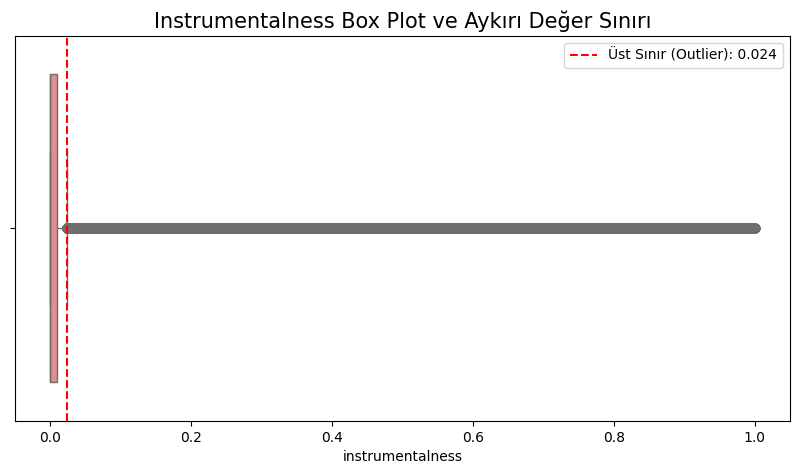

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
# instrumentalness
instrumentalness_lb, instrumentalness_ub = get_outliers(df['instrumentalness'])
print(f"Instrumentalness Sınırları: Alt={instrumentalness_lb:.3f}, Üst={instrumentalness_ub:.3f}")

# Görselleştirme
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['instrumentalness'], color='lightcoral')
plt.axvline(instrumentalness_ub, color='red', linestyle='--', label=f'Üst Sınır (Outlier): {instrumentalness_ub:.3f}')
plt.title('Instrumentalness Box Plot ve Aykırı Değer Sınırı', fontsize=15)
plt.legend()
plt.show()



*   Şarkıların büyük çoğunluğu (%75-80'den fazlası) vokal içerir. Bu yüzden instrumentalness değerleri 0'a çok yakındır.
*   0.024 seçilir ise büyük değerleri kaybeder ve enstrümantal şarkıların ayırt edici özelliğini kaybedilir.



In [18]:
# danceability, energy, speechiness, acousticness, liveness, valence > 0
# instrumentalness lower=-0.014, upper=0.024
clip_targets = {
    'popularity': (0, 83), #0 - 100
    'danceability': (0, 1),
    'energy': (0, 1),
    'loudness': (-22.5, 0), #-60 - 0
    'speechiness': (0, 0.14), #0 - 1
    'acousticness': (0, 1),
    'liveness': (0, 0.54),
    'valence': (0, 1),
    'tempo': (34.5, 197.4)
}

#['loudness', 'tempo', 'liveness', 'speechiness', 'instrumentalness']
for col, (lb, ub) in clip_targets.items():
    if col in df.columns:
        df[col] = df[col].clip(lower=lb, upper=ub)

In [19]:
# Skewness Değerler
  # 0'a yakın ise normal dağılım
  # Pozitif (> 0.5 veya 1.0): Sağa çarpık (Kuyruk sağda, verilerin çoğu solda/küçük değerlerde toplanmış).
  # Negatif (< -0.5 veya -1.0): Sola çarpık (Kuyruk solda, verilerin çoğu sağda/büyük değerlerde toplanmış).
import numpy as np
skewed_features = ['speechiness', 'instrumentalness', 'liveness']
#speechiness	3.693696
#instrumentalness	2.270804
#liveness	2.044862
#tempo	0.403328
#popularity	0.278648
#acousticness	0.151338
#energy	-0.131492
#valence	-0.152398
#danceability	-0.331015
#loudness	-1.236138

for col in skewed_features:
  df[f'{col}_log'] = np.log1p(df[col])


In [20]:
df[['speechiness_log', 'instrumentalness_log', 'liveness_log']].skew()

,0
speechiness_log,1.126802
instrumentalness_log,2.163182
liveness_log,1.024622


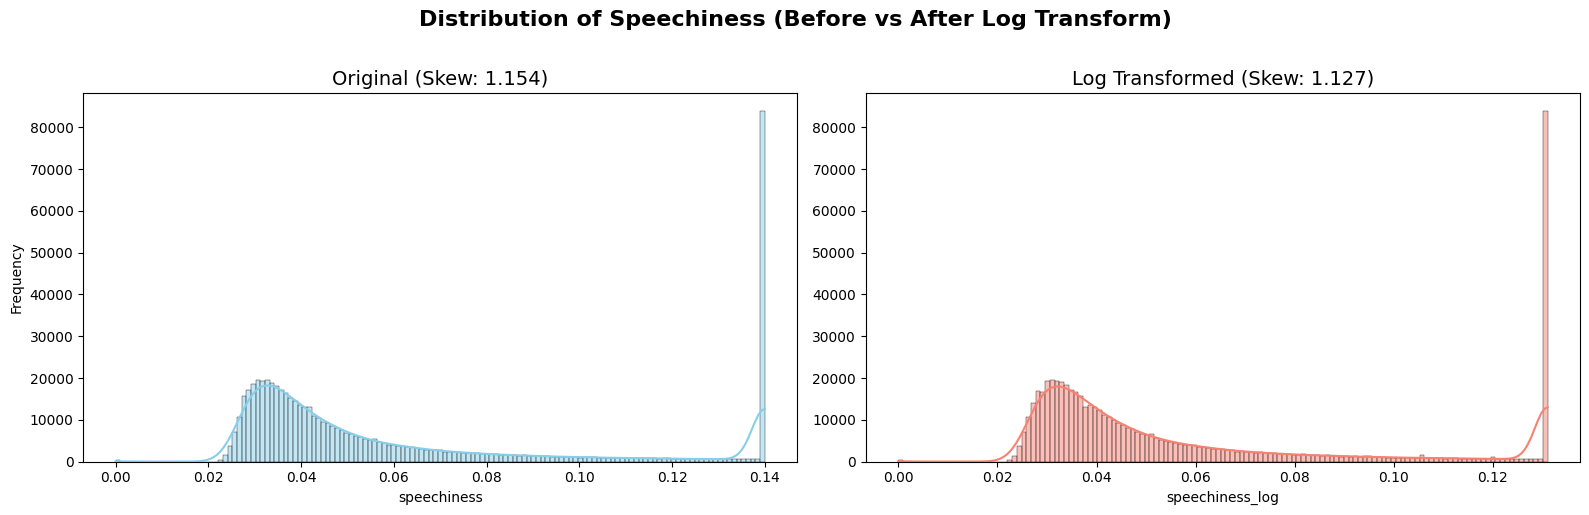

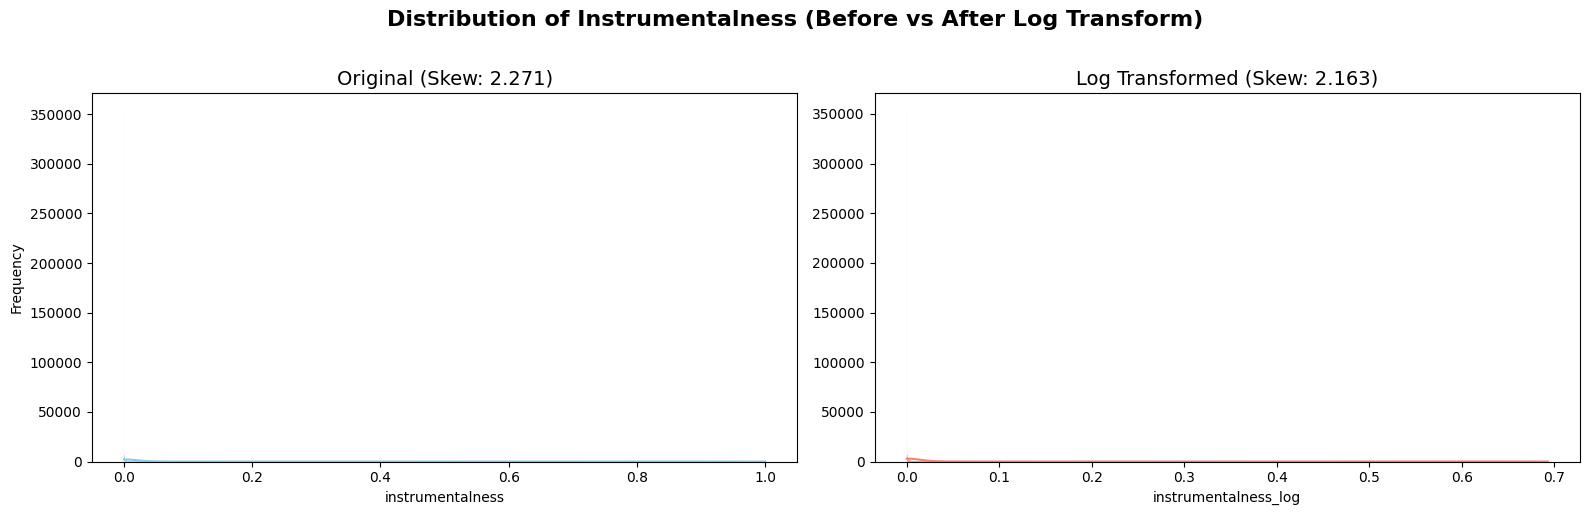

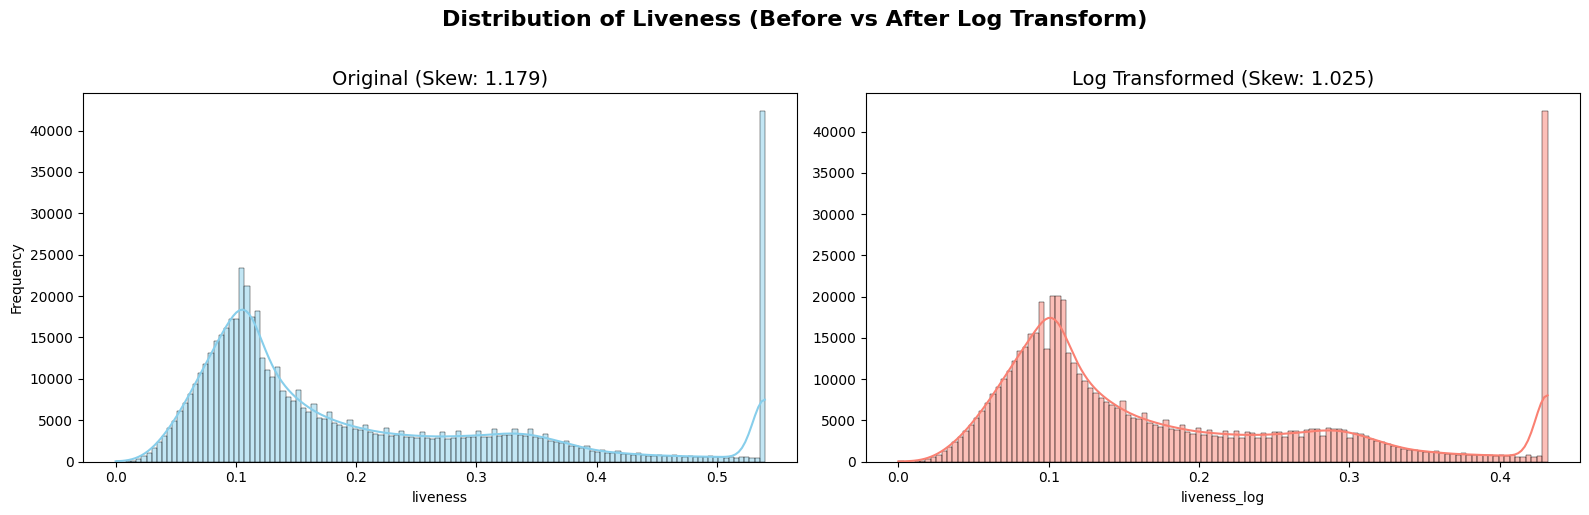

Dönüşüm ve görselleştirme tamamlandı.


In [28]:
# Her özellik için yan yana iki grafik (Orijinal vs Log) oluştur
for col in skewed_features:
    # 1 satır, 2 sütun düzeni
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Ana başlık (Özellik adı ve Skewness değerleri)
    old_skew = df[col].skew()
    new_skew = df[f'{col}_log'].skew()
    fig.suptitle(f'Distribution of {col.capitalize()} (Before vs After Log Transform)', fontsize=16, fontweight='bold', y=1.02)

    # 1. Grafik: Orijinal Dağılım
    sns.histplot(df[col], kde=True, color='skyblue', ax=axes[0], edgecolor='black')
    axes[0].set_title(f'Original (Skew: {old_skew:.3f})', fontsize=14)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    # 2. Grafik: Log Dönüşümlü Dağılım
    sns.histplot(df[f'{col}_log'], kde=True, color='salmon', ax=axes[1], edgecolor='black')
    axes[1].set_title(f'Log Transformed (Skew: {new_skew:.3f})', fontsize=14)
    axes[1].set_xlabel(f'{col}_log')
    axes[1].set_ylabel('') # Y ekseni etiketini silelim, soldakiyle aynı

    plt.tight_layout()
    plt.show()

print("Dönüşüm ve görselleştirme tamamlandı.")

In [21]:
df.columns

Index(['id', 'name', 'popularity', 'duration_ms', 'explicit', 'artists',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'year', 'main_artist',
       'speechiness_log', 'instrumentalness_log', 'liveness_log'],
      dtype='object')

## Feature Engineering

In [22]:
# track_age -- popülerlik farkını yakalamak
# decade -- 80s, 90s, 2000s vb.
# tempo_category -- ritmi 'Slow', 'Mid-tempo', 'Fast'
# mood_category -- 'sad', 'neutral', 'happy'
# energy_level -- 'Low', 'Medium', 'High'
# instrumental_flag -- 'vocal' < 0.5 =< 'instrumental'
# speechiness_class --  'music', 'speechy', 'spoken_word'
# artist_track_count -- şarkıcının kaç şarkısı var
# popularity_group -- 'low', 'medium', 'high'
# ??

# track_age
current_year = 2024
df['track_age'] = current_year - df['year']
df['track_age'] = df['track_age'].fillna(df['track_age'].median())

# decade
df['decade'] = (df['year'] // 10) * 10
df['decade'] = df['decade'].fillna(0)

# tempo_category
def tempo_category(x):
    if x < 75:
        return 'slow'
    elif x < 120:
        return 'medium'
    elif x < 180:
        return 'fast'
    else:
        return 'very_fast'

df['tempo_category'] = df['tempo'].apply(tempo_category)

# mood_category
def mood_category(x):
    if x < 0.33:
        return 'sad'
    elif x < 0.66:
        return 'neutral'
    else:
        return 'happy'

df['mood'] = df['valence'].apply(mood_category)

#energy_level
def energy_level(x):
    if x < 0.33:
        return 'low'
    elif x < 0.66:
        return 'medium'
    else:
        return 'high'

df['energy_level'] = df['energy'].apply(energy_level)

#instrumental_flag
df['instrumental_flag'] = df['instrumentalness'].apply(lambda x: 'vocal' if x < 0.5 else  'instrumental')

# speechiness_class
def speechiness_class(x):
    if x < 0.33:
        return 'music'
    elif x < 0.66:
        return 'speechy'
    else:
        return 'spoken_word'

df['speechiness_class'] = df['speechiness'].apply(speechiness_class)

# artist_track_count
artist_counts = df['main_artist'].value_counts()
df['artist_track_count'] = df['main_artist'].map(artist_counts)

#popularity_group
def popularity_group(x):
    if x < 20:
        return 'low'
    elif x < 50:
        return 'medium'
    else:
        return 'high'

df['popularity_category'] = df['popularity'].apply(popularity_group)






In [23]:
df[['track_age', 'decade', 'tempo_category', 'mood', 'energy_level',
    'instrumental_flag', 'speechiness_class', 'artist_track_count', 'popularity_category']].head()

,track_age,decade,tempo_category,mood,energy_level,instrumental_flag,speechiness_class,artist_track_count,popularity_category
0,102.0,1920.0,medium,sad,medium,instrumental,music,6,low
1,102.0,1920.0,medium,neutral,low,vocal,music,50,low
2,102.0,1920.0,fast,neutral,low,vocal,music,560,low
3,102.0,1920.0,fast,neutral,low,instrumental,music,560,low
4,27.0,0.0,medium,sad,low,vocal,music,67,low


### Yeni eklenen özellikler hedef değişkeni olan "popülerliği" ne kadar açıklıyor?

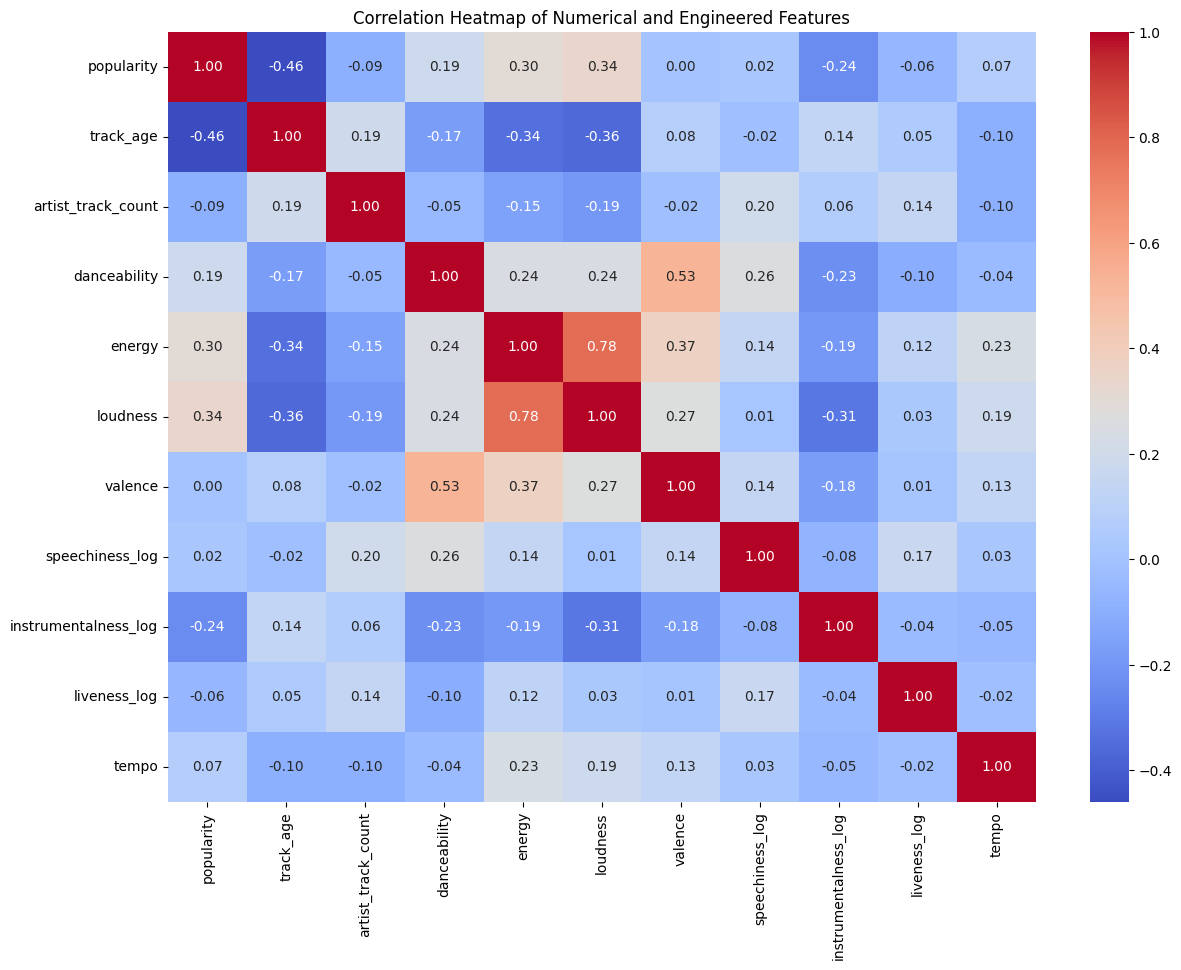

In [24]:

#[
#    'danceability', 'energy', 'loudness', 'valence',
#    'speechiness', 'acousticness', 'instrumentalness',
#    'liveness', 'tempo'
#]
# ['speechiness_log', 'instrumentalness_log', 'liveness_log']

engineered_cols = [
    'popularity', 'track_age', 'artist_track_count',
    'danceability', 'energy', 'loudness', 'valence',
    'speechiness_log', 'instrumentalness_log', 'liveness_log', 'tempo'
]

plt.figure(figsize=(14, 10))
sns.heatmap(df[engineered_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical and Engineered Features")
plt.show()



* En Güçlü Belirleyici: track_age (-0.46)
    *   Popürlerlik üzerinde en önemli özellik şarkının yaşı(track_age)
    *   Popülerlik ile track_age arasında güçlü negatif bir korelasyon var.
    *   Hit olma durumunda şarkının, modelde en büyük katkıyı track_age verecektir.

* track_age vs energy (-0.34) & track_age vs loudness(-0.36) arasında negatif bir ilişki var.
    *   Şarkıların yaşı azaldıkça, enerji ve ses yüksekliği artıyor.

* Popülerlik üzerinde etkili ses özellikleri (pozitifler)
    *   loudness (0.34),
    *   energy (0.30),
    *   danceability (0.19)    

* instrumentalness_log ve Popülerlik (-0.24)
    *   Enstrümantellik ile popülerlik arasında negatif bir ilişki var.

* artist_track_count (-0.09)
    *   Sanatçının şarkı sayısıyla ile şarkının popülerliği arasında neredeyse hiç bağ yok.



    


In [25]:
df.columns

Index(['id', 'name', 'popularity', 'duration_ms', 'explicit', 'artists',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'year', 'main_artist',
       'speechiness_log', 'instrumentalness_log', 'liveness_log', 'track_age',
       'decade', 'tempo_category', 'mood', 'energy_level', 'instrumental_flag',
       'speechiness_class', 'artist_track_count', 'popularity_category'],
      dtype='object')

In [26]:
df_numeric_columns=df.select_dtypes(include=['int64', 'float64']).columns
df_numeric_columns

Index(['popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'year', 'speechiness_log', 'instrumentalness_log', 'liveness_log',
       'track_age', 'decade', 'artist_track_count'],
      dtype='object')

In [27]:
#['speechiness_log', 'instrumentalness_log', 'liveness_log']

#['popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
#       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
#       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
#       'year', 'speechiness_log', 'instrumentalness_log', 'liveness_log',
#       'track_age', 'decade', 'artist_track_count']
features = [ 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'acousticness', 'valence', 'tempo',
        'speechiness_log', 'instrumentalness_log', 'liveness_log']
df[features].head()



,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,acousticness,valence,tempo,speechiness_log,instrumentalness_log,liveness_log
0,6,126.903,0,0.645,0.4450,0,-13.338,1,0.674,0.127,104.851,0.131028,0.556181,0.140631
1,0,98.200,0,0.695,0.2630,0,-22.136,1,0.797,0.655,102.009,0.131028,0.000000,0.138021
2,0,181.640,0,0.434,0.1770,1,-21.180,1,0.994,0.457,130.418,0.049932,0.021566,0.192272
3,0,176.907,0,0.321,0.0946,7,-22.500,1,0.995,0.397,169.980,0.049171,0.651283,0.098940
4,0,163.080,0,0.402,0.1580,3,-16.900,0,0.989,0.196,103.220,0.038259,0.122218,0.270790


## Veriyi kümelemeye hazırlama



In [41]:
# split data
from sklearn.model_selection import train_test_split

_df = df[features].fillna(df[features].median())

X_train, X_test =  train_test_split(
    _df,
    test_size=0.3,
    random_state=42)


In [37]:
X_train.head()


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,acousticness,valence,tempo,speechiness_log,instrumentalness_log,liveness_log
5811,0,199.347,0,0.290,0.414,0,-9.128,0,0.989,0.4810,104.422,0.032564,0.000189,0.250759
586185,25,226.773,0,0.182,0.147,2,-20.933,1,0.971,0.0389,96.233,0.032274,0.135405,0.170586
539040,29,267.146,0,0.560,0.595,0,-7.271,1,0.311,0.4240,133.556,0.026934,0.000000,0.124869
1340,1,173.760,0,0.568,0.156,11,-16.906,1,0.996,0.8000,186.689,0.131028,0.550431,0.189794
158869,65,174.297,0,0.801,0.834,5,-2.008,1,0.202,0.9460,94.010,0.103459,0.000000,0.064195


## KMeans ile Kümeleme

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
).assign(original_index=X_train.index)

X_text_scaled = pd.DataFrame(
    scaler.fit_transform(X_test),
    columns=X_test.columns
).assign(original_index=X_test.index)

In [43]:
print(X_scaled.columns)

Index(['popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'acousticness', 'valence', 'tempo',
       'speechiness_log', 'instrumentalness_log', 'liveness_log',
       'original_index'],
      dtype='object')


In [44]:
X_scaled.columns

Index(['popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'acousticness', 'valence', 'tempo',
       'speechiness_log', 'instrumentalness_log', 'liveness_log',
       'original_index'],
      dtype='object')

In [75]:
X_scaled_without_index = X_scaled[[c for c in X_scaled.columns if c != "original_index"]]


In [76]:
from sklearn.cluster import KMeans
nb_clusters_to_try = np.arange(1, 21, 1)
inertias = []

for nb in nb_clusters_to_try:
    kmeans = KMeans(n_clusters=nb, random_state=42)
    kmeans.fit(X_scaled_without_index)
    inertias.append(kmeans.inertia_)


In [ ]:
#df.groupby('cluster_kmeans')[features].mean()

In [77]:
import plotly.express as px

fig = px.line(y=inertias,
              x=range(1, len(inertias) + 1),
              labels={'x': 'nb centroids', 'y':'Inertia'},
              title="Elbow method")
fig.show()

In [78]:
clusters = 8

kmeans = KMeans(n_clusters=clusters, n_init='auto', max_iter=300)
# X_scaled_without_index = X_scaled[[c for c in X_scaled.columns if c != "original_index"]]

kmeans.fit(X_scaled_without_index)

kmeans_labelling = kmeans.labels_

In [79]:
np.unique(kmeans_labelling,return_counts=True)


(array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32),
 array([53303, 34055, 18104, 73451, 85083, 67172, 44422, 35030]))

In [82]:
X_scaled_without_index["kmeans_label"] = pd.Series(
    kmeans_labelling,
    index=X_scaled_without_index.index
)

In [81]:
X_scaled_without_index.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,acousticness,valence,tempo,speechiness_log,instrumentalness_log,liveness_log
0,-1.499553,-0.241425,-0.214887,-1.646563,-0.506425,-1.483436,0.206806,-1.390768,1.543014,-0.276662,-0.472563,-0.754616,-0.438773,0.678111
1,-0.139537,-0.024190,-0.214887,-2.296375,-1.565866,-0.915006,-2.279721,0.719027,1.491437,-1.992024,-0.749923,-0.762770,0.253956,-0.043287
2,0.078066,0.295595,-0.214887,-0.022033,0.211772,-1.483436,0.597952,0.719027,-0.399732,-0.497824,0.514198,-0.912669,-0.439741,-0.454655
3,-1.445153,-0.444094,-0.214887,0.026101,-1.530154,1.642930,-1.431500,0.719027,1.563072,0.961068,2.313799,2.009602,2.380195,0.129542
4,2.036489,-0.439841,-0.214887,1.428010,1.160111,-0.062361,1.706516,0.719027,-0.712061,1.527552,-0.825215,1.235633,-0.439741,-1.000607


In [83]:
X_text_scaled.columns

Index(['popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'acousticness', 'valence', 'tempo',
       'speechiness_log', 'instrumentalness_log', 'liveness_log',
       'original_index'],
      dtype='object')

In [84]:
X_test_scaled_without_index = X_text_scaled[[c for c in X_text_scaled.columns if c != "original_index"]]


In [85]:
test_labels = kmeans.predict(X_test_scaled_without_index)

In [86]:

X_test_scaled_without_index["kmeans_label"] = pd.Series(
    test_labels,
    index=X_test_scaled_without_index.index)

In [87]:
X_scaled_without_index.head(10)

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,acousticness,valence,tempo,speechiness_log,instrumentalness_log,liveness_log,kmeans_label
0,-1.499553,-0.241425,-0.214887,-1.646563,-0.506425,-1.483436,0.206806,-1.390768,1.543014,-0.276662,-0.472563,-0.754616,-0.438773,0.678111,3
1,-0.139537,-0.024190,-0.214887,-2.296375,-1.565866,-0.915006,-2.279721,0.719027,1.491437,-1.992024,-0.749923,-0.762770,0.253956,-0.043287,3
2,0.078066,0.295595,-0.214887,-0.022033,0.211772,-1.483436,0.597952,0.719027,-0.399732,-0.497824,0.514198,-0.912669,-0.439741,-0.454655,4
3,-1.445153,-0.444094,-0.214887,0.026101,-1.530154,1.642930,-1.431500,0.719027,1.563072,0.961068,2.313799,2.009602,2.380195,0.129542,1
4,2.036489,-0.439841,-0.214887,1.428010,1.160111,-0.062361,1.706516,0.719027,-0.712061,1.527552,-0.825215,1.235633,-0.439741,-1.000607,4
5,1.220479,0.557725,-0.214887,-1.339708,1.469610,0.221854,1.280615,-1.390768,-1.289220,-0.528865,1.987362,-0.586642,-0.439741,1.627555,6
6,0.132466,-0.364569,-0.214887,1.115138,1.759270,1.358714,1.150865,0.719027,0.230658,-0.043861,0.057871,0.698940,-0.193687,0.789458,4
7,2.798098,-0.666929,4.653617,2.234258,0.041151,1.358714,0.155201,-1.390768,-0.972813,0.243262,-0.622572,2.009602,-0.439741,-0.759978,2
8,0.404470,0.068435,-0.214887,-1.111070,0.148285,0.790284,0.020606,0.719027,0.588834,-0.012820,0.468135,1.134194,2.775244,-0.639197,1
9,0.894075,0.092514,-0.214887,-1.610463,-0.292156,-0.915006,0.497480,-1.390768,0.216331,-1.677354,-1.339290,-0.847160,-0.439741,-0.227240,3


In [89]:
print(X_text_scaled.index.equals(X_test_scaled_without_index.index))

True


In [90]:
predict_tracks_trained = pd.concat([X_text_scaled, X_test_scaled_without_index], axis=1)

In [91]:
# KMeans
predict_tracks = df.loc[predict_tracks_trained['original_index'], ['name', 'artists']].copy()

# kmeans_label ekleme

predict_tracks['kmeans_label'] = predict_tracks_trained['kmeans_label'].values

predict_tracks.head(10)

,name,artists,kmeans_label
113799,Sailing Airwaves (In Memory of Matt Trigle),"[ReOrder, STANDERWICK, Sky Patrol]",6
134814,Twelfth street rag,"[Andy Kirk & His 12 clouds of Joy, Andy Kirk]",7
216564,Por Fin,[Los Dandys],0
266481,"Toccata in D Major, BWV 912","[Johann Sebastian Bach, Glenn Gould]",1
120490,Paryż-moskwa 17.15,[Obywatel G.C],5
34218,Rhumba No. 2,[Ahmad Jamal],1
530897,Oru Nokku,[Karthik],3
229519,אצא לי אל היער,[Uzi Hitman],0
134081,Jig time,[The Three Keys],0
349190,Herederos de una Historia,[Estirpe Imperial],5


## DBSCAN ile kümeleme

In [45]:
X_scaled.columns

Index(['popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'acousticness', 'valence', 'tempo',
       'speechiness_log', 'instrumentalness_log', 'liveness_log',
       'original_index'],
      dtype='object')

In [46]:
db_X_scaled_without_index = X_scaled[[c for c in X_scaled.columns if c != "original_index"]]

In [48]:
from sklearn.cluster import DBSCAN
features = [
    'danceability', 'energy', 'loudness', 'valence', 'tempo',
    'acousticness', 'instrumentalness', 'liveness',
    'speechiness', 'track_age', 'artist_track_count'
]

# Min samples estimate is calculate here as n_features * 2
epsilon = [1.7]
min_samples = len(db_X_scaled_without_index.columns) * 2

dbscan = DBSCAN(eps=epsilon[0], min_samples=min_samples, algorithm="ball_tree",
    n_jobs=-1)

dbscan.fit(db_X_scaled_without_index)

DBSCAN(algorithm='ball_tree', eps=1.7, min_samples=28, n_jobs=-1)

In [53]:
dbscan_labels = dbscan.labels_

np.unique(dbscan_labels, return_counts=True)

(array([-1,  0,  1,  2,  3,  4,  5]),
 array([ 15953, 125540, 254045,   6957,   8083,     18,     24]))

In [54]:
df["dbscan_label"] = pd.Series(dbscan_labels)
df.head(10)

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,track_age,decade,tempo_category,mood,energy_level,instrumental_flag,speechiness_class,artist_track_count,popularity_category,dbscan_label
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126.903,0,[Uli],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,...,102.0,1920.0,medium,sad,medium,instrumental,music,6,low,0.0
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98.200,0,[Fernando Pessoa],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,...,102.0,1920.0,medium,neutral,low,vocal,music,50,low,1.0
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181.640,0,[Ignacio Corsini],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,...,102.0,1920.0,fast,neutral,low,vocal,music,560,low,1.0
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176.907,0,[Ignacio Corsini],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,...,102.0,1920.0,fast,neutral,low,instrumental,music,560,low,1.0
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163.080,0,[Dick Haymes],['3BiJGZsyX9sJchTqcSA7Su'],NaT,0.402,0.1580,...,27.0,0.0,medium,sad,low,vocal,music,67,low,1.0
5,0BRXJHRNGQ3W4v9frnSfhu,Ave Maria,0,178.933,0,[Dick Haymes],['3BiJGZsyX9sJchTqcSA7Su'],NaT,0.227,0.2610,...,27.0,0.0,medium,sad,low,vocal,music,67,low,0.0
6,0Dd9ImXtAtGwsmsAD69KZT,La Butte Rouge,0,134.467,0,[Francis Marty],['2nuMRGzeJ5jJEKlfS7rZ0W'],NaT,0.510,0.3550,...,27.0,0.0,medium,happy,medium,vocal,music,1,low,1.0
7,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161.427,0,[Mistinguett],['4AxgXfD7ISvJSTObqm4aIE'],NaT,0.563,0.1840,...,27.0,0.0,fast,neutral,low,vocal,music,25,low,2.0
8,0IgI1UCz84pYeVetnl1lGP,Old Fashioned Girl,0,310.073,0,[Greg Fieler],['5nWlsH5RDgFuRAiDeOFVmf'],NaT,0.488,0.4750,...,27.0,0.0,fast,neutral,medium,vocal,music,1,low,-1.0
9,0JV4iqw2lSKJaHBQZ0e5zK,Martín Fierro - Remasterizado,0,181.173,0,[Ignacio Corsini],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-29,0.548,0.0391,...,102.0,1920.0,medium,neutral,low,instrumental,music,560,low,0.0


## KMeans ve DBScan Karşılaştırması

In [28]:
df.columns


Index(['id', 'name', 'popularity', 'duration_ms', 'explicit', 'artists',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'year', 'main_artist',
       'speechiness_log', 'instrumentalness_log', 'liveness_log', 'track_age',
       'decade', 'tempo_category', 'mood', 'energy_level', 'instrumental_flag',
       'speechiness_class', 'artist_track_count', 'popularity_category'],
      dtype='object')

In [29]:
features

['popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'acousticness',
 'valence',
 'tempo',
 'speechiness_log',
 'instrumentalness_log',
 'liveness_log']

In [30]:
X = df[features].copy()


In [31]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()

X_scaled = pd.DataFrame(robust_scaler.fit_transform(X),
                             columns=X.columns)

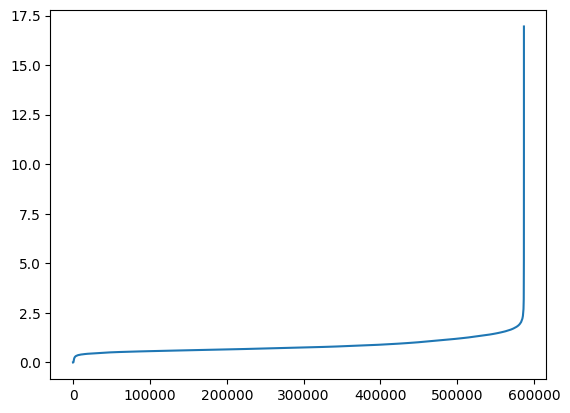

In [98]:
# bi daha calistirma.
#from sklearn.preprocessing import RobustScaler

#robust_scaler = RobustScaler()

#X_scaled = pd.DataFrame(robust_scaler.fit_transform(X),
#                              columns=X.columns)


#from sklearn.neighbors import NearestNeighbors
#neighbors = NearestNeighbors(n_neighbors=8)
#neighbors_fit = neighbors.fit(X_scaled)

#distances, indices = neighbors_fit.kneighbors(X_scaled)
#distances = np.sort(distances, axis=0)
#average_distances = np.mean(distances[:, 1:], axis=1)
#plt.plot(average_distances);

In [33]:
# dbscan test
from sklearn.cluster import DBSCAN
X_scaled_32 = X_scaled.astype("float32")
#eps = 2.0 patladi ram
X_sample = X_scaled_32.sample(200_000, random_state=42)

dbscan = DBSCAN(
    eps = 1.6,
    min_samples=10,       # düşük tutuyoruz (hız için)
    algorithm="ball_tree",
    n_jobs=-1
)

dbscan_labels = dbscan.fit_predict(X_sample)

KeyboardInterrupt: 

In [34]:
X_sample = X_scaled_32.sample(80_000, random_state=42)

dbscan = DBSCAN(
    eps=1.5,
    min_samples=10,
    n_jobs=-1
)

labels_sample = dbscan.fit_predict(X_sample)

In [36]:
np.unique(labels_sample,return_counts=True)


(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]),
 array([12753, 63253,  3548,    72,    82,    21,     7,    12,     9,
           11,    10,    25,    17,    15,    17,    10,     5,    14,
           18,    11,    10,    10,     9,    11,     5,    10,     9,
           15,    11]))

In [95]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

In [32]:
# KMeans
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=8, random_state=42, n_init='auto')
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_df = df.copy()
kmeans_df["cluster"] = kmeans_labels
kmeans_df["model"] = "kmeans"

In [33]:
np.unique(kmeans_labels,return_counts=True)


(array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32),
 array([ 13468, 353017,  46496,  14680, 117694,    915,  22621,  17710]))

In [34]:
# HDBScan
import hdbscan
from sklearn.decomposition import PCA

X_pca = PCA(n_components=14).fit_transform(X_scaled)

# HDBSCAN modeli
hdb = hdbscan.HDBSCAN(
    min_samples=10,         # her core point için minimum komşu
    min_cluster_size=50,    # oluşturulacak minimum küme boyutu
    cluster_selection_method='eom'  # 'eom' veya 'leaf'
)

# Fit ve predict
hdb_labels = hdb.fit_predict(X_pca)

# Sonuçları df'e ekleme
dbscan_df = df.copy()
dbscan_df["cluster"] = hdb_labels
dbscan_df["model"] = "hdbscan"

In [36]:
np.unique(hdb_labels, return_counts=True)

(array([-1,  0,  1]), array([  1614,     50, 584937]))

In [35]:
dbscan_df

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,decade,tempo_category,mood,energy_level,instrumental_flag,speechiness_class,artist_track_count,popularity_category,cluster,model
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126.903,0,[Uli],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,...,1920.0,medium,sad,medium,instrumental,music,6,low,1,hdbscan
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98.200,0,[Fernando Pessoa],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,...,1920.0,medium,neutral,low,vocal,music,50,low,1,hdbscan
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181.640,0,[Ignacio Corsini],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,...,1920.0,fast,neutral,low,vocal,music,560,low,1,hdbscan
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176.907,0,[Ignacio Corsini],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,...,1920.0,fast,neutral,low,instrumental,music,560,low,1,hdbscan
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163.080,0,[Dick Haymes],['3BiJGZsyX9sJchTqcSA7Su'],NaT,0.402,0.1580,...,0.0,medium,sad,low,vocal,music,67,low,1,hdbscan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586667,5rgu12WBIHQtvej2MdHSH0,云与海,50,258.267,0,[阿YueYue],['1QLBXKM5GCpyQQSVMNZqrZ'],2020-09-26,0.560,0.5180,...,2020.0,fast,sad,medium,vocal,music,1,high,1,hdbscan
586668,0NuWgxEp51CutD2pJoF4OM,blind,72,153.293,0,[ROLE MODEL],['1dy5WNgIKQU6ezkpZs4y8z'],2020-10-21,0.765,0.6630,...,2020.0,fast,happy,high,vocal,music,1,high,1,hdbscan
586669,27Y1N4Q4U3EfDU5Ubw8ws2,What They'll Say About Us,70,187.601,0,[FINNEAS],['37M5pPGs6V1fchFJSgCguX'],2020-09-02,0.535,0.3140,...,2020.0,fast,sad,low,vocal,music,6,high,1,hdbscan
586670,45XJsGpFTyzbzeWK8VzR8S,A Day At A Time,58,142.003,0,"[Gentle Bones, Clara Benin]","['4jGPdu95icCKVF31CcFKbS', '5ebPSE9YI5aLeZ1Z2g...",2021-03-05,0.696,0.6150,...,2020.0,medium,neutral,medium,vocal,music,8,high,1,hdbscan


In [ ]:
def analyze_clusters(df, model_name):
    result = (
        df.groupby("cluster")
        .agg(
            avg_popularity=("popularity", "mean"),
            count=("popularity", "count"),
            danceability=("danceability", "mean"),
            energy=("energy", "mean"),
            valence=("valence", "mean")
        )
        .sort_values("avg_popularity", ascending=False)
    )

    print(f"\n {model_name.upper()} ANALYSIS")
    return result

In [99]:
X.shape

(586601, 14)